# Week 3 - Data Visualization & Statistics Basics
**Deliverable:** A short EDA report (notebook) with charts and 3-5 written insights about the dataset.

**Dataset used:** Titanic dataset (loaded via seaborn's built-in dataset loader) - same as Week 2, after re-applying the same cleaning steps.

In [1]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

## 1. Load the Cleaned Dataset
We reload the raw Titanic dataset and re-apply the same cleaning steps used in the Week 2 notebook.

In [3]:
raw_df = sns.load_dataset('titanic')

df = raw_df.copy()
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df = df.drop(columns=['deck'])

print('Shape after cleaning:', df.shape)
df.head()

Shape after cleaning: (891, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## 2. Descriptive Statistics
Mean, median, mode, variance, and standard deviation for the key numeric columns.

In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
num_cols = ['age', 'fare', 'sibsp', 'parch']

stats = pd.DataFrame({
    'mean': df[num_cols].mean(),
    'median': df[num_cols].median(),
    'mode': df[num_cols].mode().iloc[0],
    'variance': df[num_cols].var(),
    'std_dev': df[num_cols].std()
})
stats

,mean,median,mode,variance,std_dev
age,29.361582,28.0000,28.00,169.512498,13.019697
fare,32.204208,14.4542,8.05,2469.436846,49.693429
sibsp,0.523008,0.0000,0.00,1.216043,1.102743
parch,0.381594,0.0000,0.00,0.649728,0.806057


## 3. Distributions - Histograms
Looking at how `age` and `fare` are spread out.

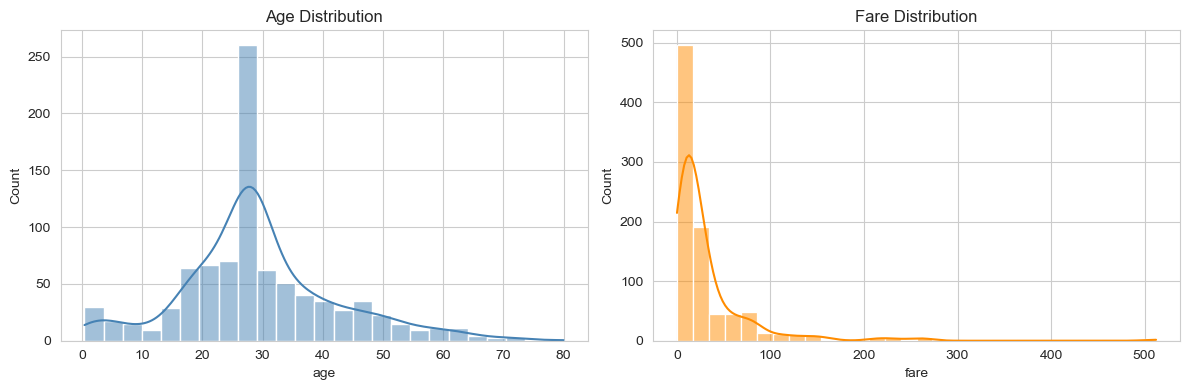

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['age'], bins=25, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['fare'], bins=30, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Fare Distribution')

plt.tight_layout()
plt.show()

## 4. Box Plots
Spread and outliers of `fare` by class, and `age` by survival.

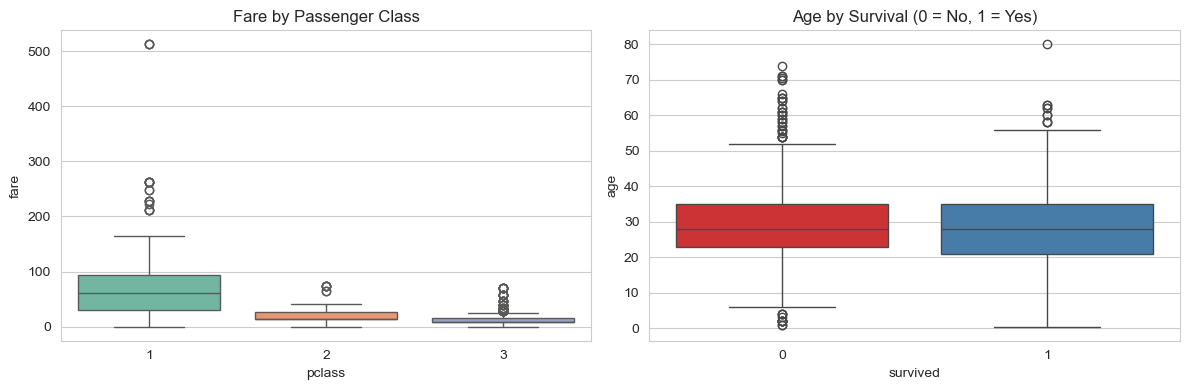

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='pclass', y='fare', data=df, hue='pclass', legend=False, palette='Set2', ax=axes[0])
axes[0].set_title('Fare by Passenger Class')

sns.boxplot(x='survived', y='age', data=df, hue='survived', legend=False, palette='Set1', ax=axes[1])
axes[1].set_title('Age by Survival (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

## 5. Scatter Plot
`age` vs `fare`, colored by survival and styled by class.

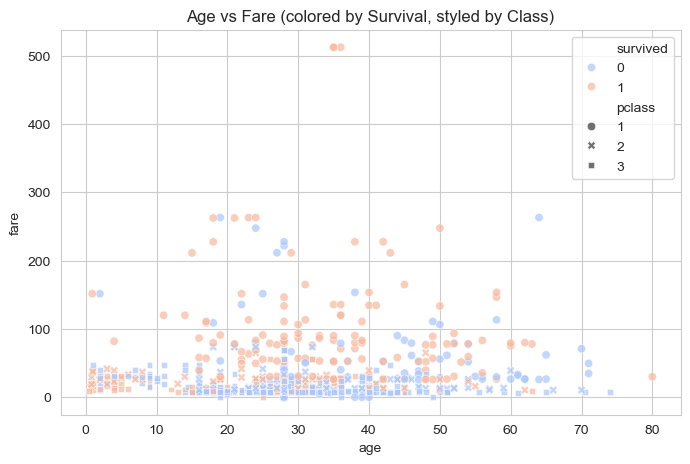

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='fare', hue='survived', style='pclass', data=df, palette='coolwarm', alpha=0.7)
plt.title('Age vs Fare (colored by Survival, styled by Class)')
plt.show()

## 6. Correlation Heatmap

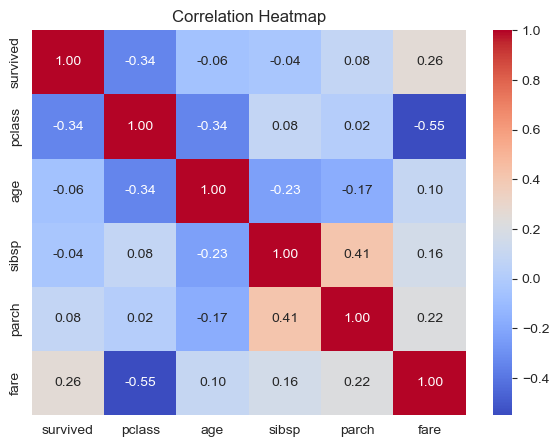

In [9]:
plt.figure(figsize=(7, 5))
corr = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 7. Quick Group Comparisons
Supporting numbers for the insights below.

In [10]:
print('Survival rate by sex:')
print(df.groupby('sex')['survived'].mean(), '\n')

print('Survival rate by class:')
print(df.groupby('pclass')['survived'].mean(), '\n')

print('Average fare by class:')
print(df.groupby('pclass')['fare'].mean())

Survival rate by sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64 

Survival rate by class:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64 

Average fare by class:
pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64


## 8. Insights

1. **Class and fare strongly relate to survival.** 1st class passengers paid a much higher average fare and survived at a noticeably higher rate than 3rd class.
2. **Women survived at a much higher rate than men** - consistent with the "women and children first" evacuation pattern.
3. **Fare and age are right-skewed, not normally distributed** - most passengers paid low fares, with a few high-fare outliers pulling the mean above the median.
4. **Age has only a weak correlation with survival**, weaker than `pclass` or `fare` - suggesting socio-economic status mattered more than age alone.
5. **`sibsp` and `parch` are positively correlated with each other**, since both describe family relationships aboard - a combined "family size" feature could be useful for modelling in later weeks.